
# Лабораторна робота №5  
## Реалізація багатошарового перцептрону з нуля в PyTorch

**Мета роботи:**  
Реалізувати багатошаровий перцептрон (MLP) *без використання autograd*, щоб краще зрозуміти,
як працює forward та backward pass у нейронних мережах.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix



Підготовка даних

Використання Wine Quality Dataset.
Дані потрібно:
- нормалізувати
- розбити на train / val / test
- перетворити у тензори PyTorch


In [2]:

def load_and_preprocess_data_from_csv(
    csv_path,
    label_column="quality",
    test_size=0.2,
    val_size=0.2
):
    df = pd.read_csv(csv_path)

    X = df.drop(label_column, axis=1).values
    y = df[label_column].values

    y = y - y.min()

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=test_size + val_size,
        random_state=42,
        stratify=y
    )

    val_ratio = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=1 - val_ratio,
        random_state=42,
        stratify=y_temp
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)

    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = load_and_preprocess_data_from_csv(
    "WineQT.csv",
    label_column="quality"
)



 Функції активації (з нуля)


In [3]:

class ActivationFunctions:
    
    @staticmethod
    def relu(x, derivative=False):
        if derivative:
            return (x > 0).float()
        return torch.maximum(torch.zeros_like(x), x)
    
    @staticmethod
    def tanh(x, derivative=False):
        if derivative:
            return 1 - torch.tanh(x) ** 2
        return torch.tanh(x)



Функція втрат: Categorical Cross-Entropy


In [4]:

class LossFunctions:
    
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
        batch_size = y_pred.shape[0]
        
        if derivative:
            grad = y_pred.clone()
            grad[range(batch_size), y_true] -= 1
            return grad / batch_size
        
        log_likelihood = -torch.log(y_pred[range(batch_size), y_true] + 1e-9)
        return torch.mean(log_likelihood)



Власна реалізація MLP


In [5]:

class CustomMLP:
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.lr = learning_rate
        
        self.parameters = {}
        
        for i in range(1, len(layer_sizes)):
            self.parameters[f"W{i}"] = torch.randn(
                layer_sizes[i], layer_sizes[i-1]
            ) * np.sqrt(2 / layer_sizes[i-1])
            self.parameters[f"b{i}"] = torch.zeros(layer_sizes[i], 1)
    
    def softmax(self, z):
        exp_z = torch.exp(z - torch.max(z, dim=0, keepdim=True)[0])
        return exp_z / torch.sum(exp_z, dim=0, keepdim=True)
    
    def forward(self, X):
        cache = {}
        A = X.T
        cache["A0"] = A
        
        for i in range(1, len(self.layer_sizes)):
            Z = self.parameters[f"W{i}"] @ A + self.parameters[f"b{i}"]
            cache[f"Z{i}"] = Z
            
            if i == len(self.layer_sizes) - 1:
                A = self.softmax(Z)
            else:
                A = self.activations[i-1](Z)
            
            cache[f"A{i}"] = A
        
        return A.T, cache
    
    def backward(self, X, y, cache):
        m = X.shape[0]
        grads = {}
        
        y_pred = cache[f"A{len(self.layer_sizes)-1}"].T
        dZ = LossFunctions.categorical_cross_entropy(y_pred, y, derivative=True).T
        
        for i in reversed(range(1, len(self.layer_sizes))):
            A_prev = cache[f"A{i-1}"]
            
            grads[f"dW{i}"] = (1/m) * dZ @ A_prev.T
            grads[f"db{i}"] = (1/m) * torch.sum(dZ, dim=1, keepdim=True)
            
            if i > 1:
                dA_prev = self.parameters[f"W{i}"].T @ dZ
                dZ = dA_prev * self.activations[i-2](
                    cache[f"Z{i-1}"], derivative=True
                )
        
        for i in range(1, len(self.layer_sizes)):
            self.parameters[f"W{i}"] -= self.lr * grads[f"dW{i}"]
            self.parameters[f"b{i}"] -= self.lr * grads[f"db{i}"]



Навчання власної моделі


In [6]:

def train_custom_mlp(model, X_train, y_train, X_val, y_val, epochs=200):
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(epochs):
        y_pred, cache = model.forward(X_train)
        loss = LossFunctions.categorical_cross_entropy(y_pred, y_train)
        model.backward(X_train, y_train, cache)
        
        val_pred, _ = model.forward(X_val)
        val_loss = LossFunctions.categorical_cross_entropy(val_pred, y_val)
        
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: train loss={loss:.4f}, val loss={val_loss:.4f}")
    
    return history


input_size = X_train.shape[1]
num_classes = len(torch.unique(y_train))

custom_model = CustomMLP(
    layer_sizes=[input_size, 32, num_classes],
    activations=[ActivationFunctions.relu],
    learning_rate=0.01
)

history_custom = train_custom_mlp(
    custom_model, X_train, y_train, X_val, y_val
)


Epoch 0: train loss=2.1230, val loss=2.1005
Epoch 20: train loss=2.1224, val loss=2.0998
Epoch 40: train loss=2.1217, val loss=2.0991
Epoch 60: train loss=2.1210, val loss=2.0985
Epoch 80: train loss=2.1204, val loss=2.0978
Epoch 100: train loss=2.1197, val loss=2.0972
Epoch 120: train loss=2.1191, val loss=2.0965
Epoch 140: train loss=2.1184, val loss=2.0958
Epoch 160: train loss=2.1178, val loss=2.0952
Epoch 180: train loss=2.1172, val loss=2.0945



Клас PyTorch, реалізація для порівняння


In [7]:

class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.net(x)


torch_model = PyTorchMLP(input_size, 32, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.01)

history_torch = {"train_loss": [], "val_loss": []}

for epoch in range(200):
    optimizer.zero_grad()
    outputs = torch_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        val_outputs = torch_model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    history_torch["train_loss"].append(loss.item())
    history_torch["val_loss"].append(val_loss.item())



візуалізація


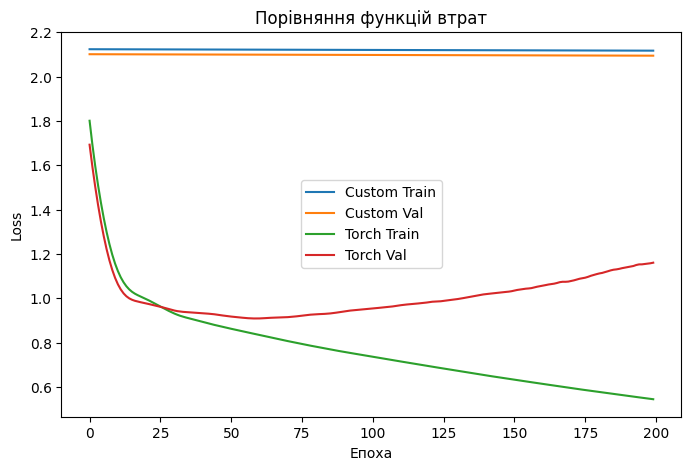

In [8]:

plt.figure(figsize=(8,5))
plt.plot(history_custom["train_loss"], label="Custom Train")
plt.plot(history_custom["val_loss"], label="Custom Val")
plt.plot(history_torch["train_loss"], label="Torch Train")
plt.plot(history_torch["val_loss"], label="Torch Val")
plt.legend()
plt.title("Порівняння функцій втрат")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.show()
